# Explainability (SHAP) and EU AI Act Compliance

Applies SHAP's TreeExplainer to the final selected model (XGBoost,
Notebook 04) to satisfy the EU AI Act's explainability requirement for
high-risk AI systems. Covers global and local explanations, plus four
robustness checks investigating why SHAP's ranking diverges from
XGBoost's native feature importance.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120

# Load engineered dataset (same as Notebook 04)
print('Loading dataset...')
train = pd.read_parquet('../data/train_engineered.parquet')
train = train.sort_values('TransactionDT').reset_index(drop=True)

TARGET    = 'isFraud'
DROP_COLS = ['TransactionID', 'TransactionDT', TARGET]
DROP_COLS += train.select_dtypes('object').columns.tolist()
DROP_COLS  = [c for c in DROP_COLS if c in train.columns]
FEATURES   = [c for c in train.columns if c not in DROP_COLS]

X = train[FEATURES]
y = train[TARGET]

split_idx = int(len(train) * 0.80)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f'Test set: {X_test.shape[0]:,} transactions')
print(f'SHAP version: {shap.__version__}')

Loading dataset...
Test set: 118,108 transactions
SHAP version: 0.51.0


In [6]:
# ── Load the saved XGBoost model from Notebook 04 ──────────────────────────────

xgb_model = joblib.load('../models/xgb_model.pkl')
print('XGBoost model loaded.')
print(f'Number of features: {len(FEATURES)}')
print(f'Number of trees: {xgb_model.get_booster().num_boosted_rounds()}')

XGBoost model loaded.
Number of features: 421
Number of trees: 1000


## SHAP TreeExplainer

TreeExplainer computes exact SHAP values for tree-based models by
exploiting the tree structure directly, rather than approximating via
sampling (as KernelExplainer would need to for CNN-LSTM).


In [ ]:
# Initialize SHAP TreeExplainer

explainer = shap.TreeExplainer(xgb_model)

# Full test set would be slow; 10K rows is enough for stable rankings
SAMPLE_SIZE = 10000
sample_idx  = np.random.RandomState(42).choice(len(X_test), SAMPLE_SIZE, replace=False)
X_sample    = X_test.iloc[sample_idx]

print(f'Computing SHAP values for {SAMPLE_SIZE:,} sampled transactions...')
shap_values = explainer.shap_values(X_sample)
print(f'SHAP values shape: {shap_values.shape}')
print('Done.')

Computing SHAP values for 10,000 sampled transactions...
SHAP values shape: (10000, 421)
Done.


## Global Feature Importance


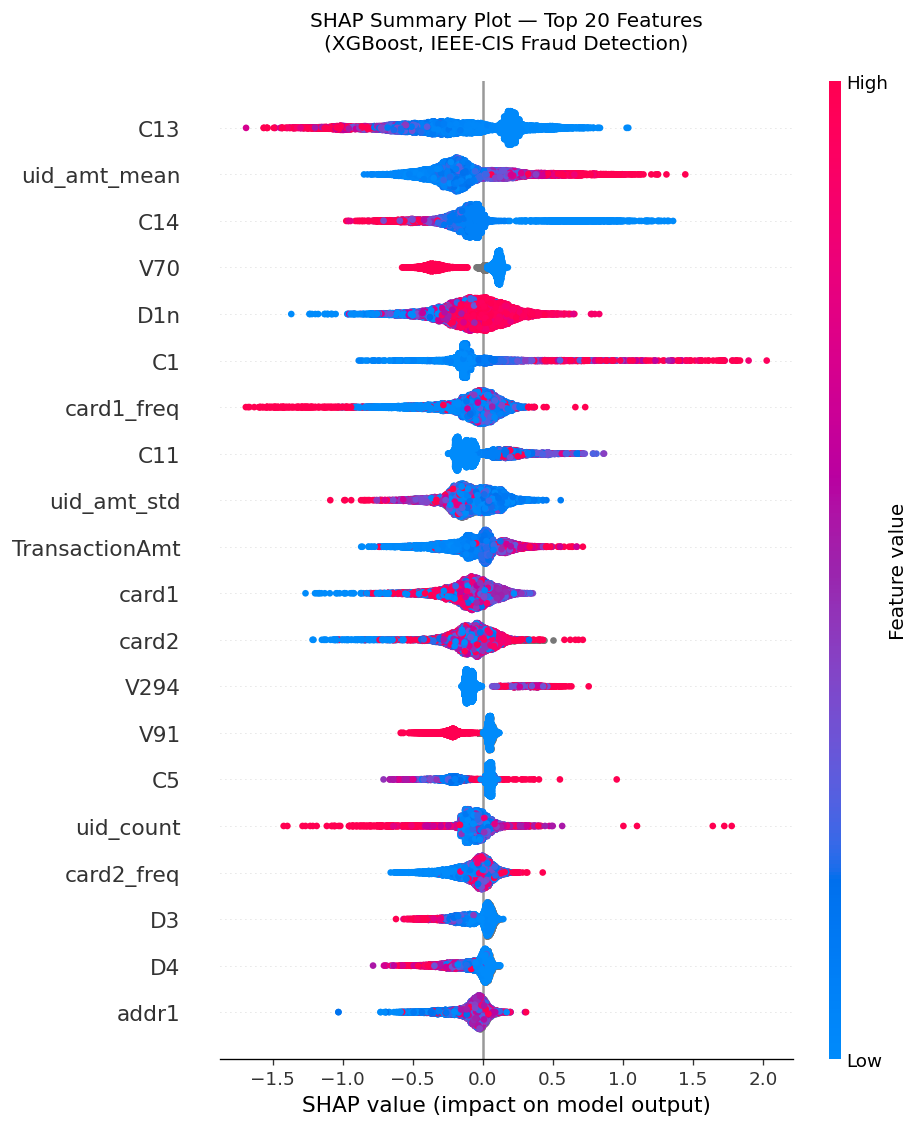

Saved: reports/shap_summary.png


In [ ]:
# SHAP Summary Plot (beeswarm)
fig = plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, max_display=20, show=False)
plt.title('SHAP Summary Plot — Top 20 Features\n(XGBoost, IEEE-CIS Fraud Detection)',
          fontsize=12, pad=20)
plt.tight_layout()
plt.savefig('../reports/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: reports/shap_summary.png')

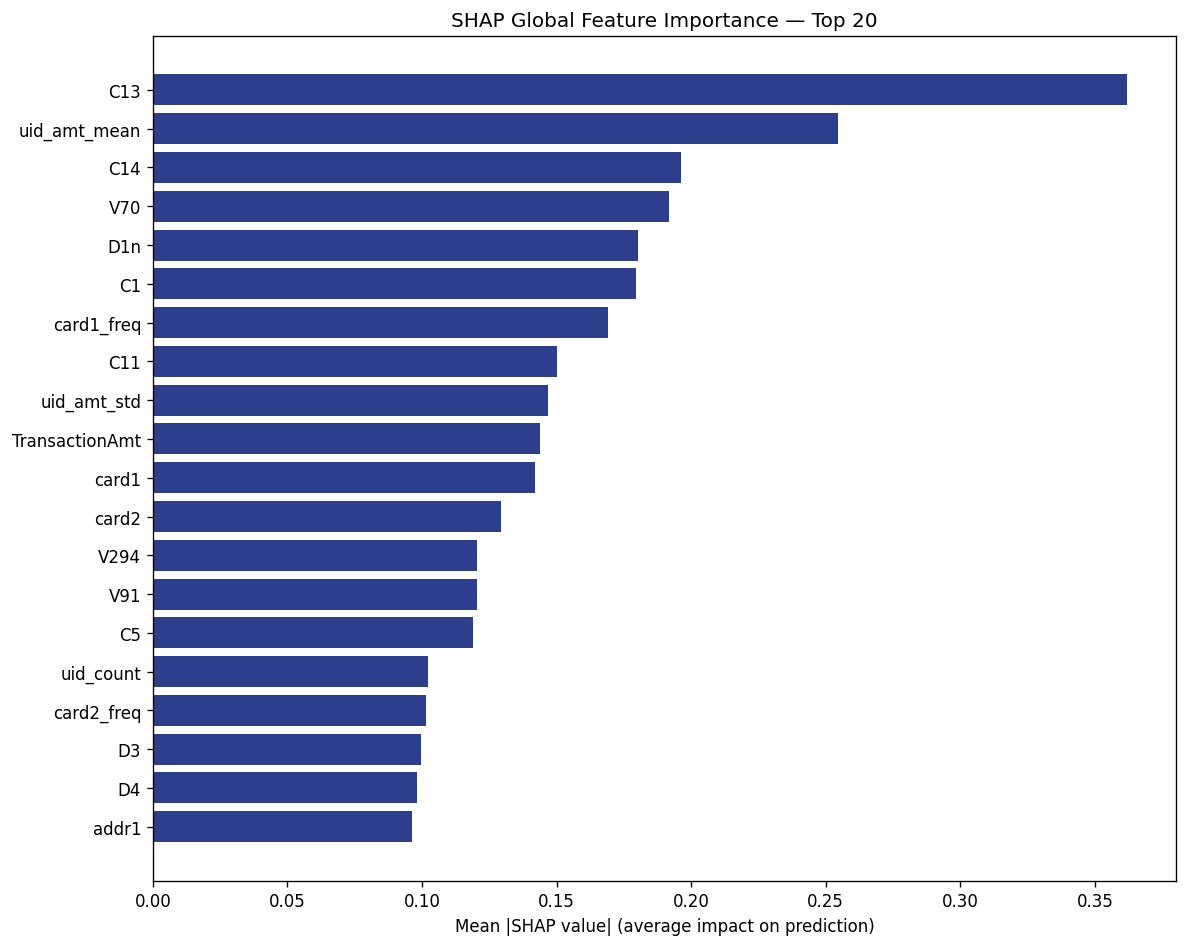

Top 10 features by SHAP importance:
       feature  mean_abs_shap
           C13       0.362053
  uid_amt_mean       0.254549
           C14       0.196109
           V70       0.191607
           D1n       0.180360
            C1       0.179430
    card1_freq       0.169184
           C11       0.150182
   uid_amt_std       0.146960
TransactionAmt       0.143940


In [ ]:
# SHAP Bar Plot (mean absolute impact, easier to read for a business audience) ─

mean_abs_shap = pd.DataFrame({
    'feature': FEATURES,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top20 = mean_abs_shap.head(20)
ax.barh(top20['feature'][::-1], top20['mean_abs_shap'][::-1], color='#2c3e8c')
ax.set_xlabel('Mean |SHAP value| (average impact on prediction)')
ax.set_title('SHAP Global Feature Importance — Top 20')
plt.tight_layout()
plt.savefig('../reports/shap_bar_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 features by SHAP importance:')
print(mean_abs_shap.head(10).to_string(index=False))

## Robustness Checks

The SHAP ranking diverges substantially from XGBoost's native (gain-based)
importance -- only 1/10 of the top features overlap. Rather than accepting
this at face value, four checks investigate why:

1. Mean vs. median SHAP (outlier sensitivity)
2. Gain vs. weight vs. cover (which native metric SHAP actually agrees with)
3. Top-N stability (is the agreement a coincidence of exactly 10 features?)
4. Correlation among UID-derived features (credit-splitting risk)


In [ ]:
# Compare SHAP ranking vs. native XGBoost feature_importances_

native_imp = pd.DataFrame({
    'feature': FEATURES,
    'native_importance': xgb_model.feature_importances_
}).sort_values('native_importance', ascending=False).reset_index(drop=True)
native_imp['native_rank'] = native_imp.index + 1

shap_imp = mean_abs_shap.reset_index(drop=True)
shap_imp['shap_rank'] = shap_imp.index + 1

comparison = shap_imp[['feature', 'shap_rank']].merge(
    native_imp[['feature', 'native_rank']], on='feature'
)
comparison['rank_diff'] = abs(comparison['shap_rank'] - comparison['native_rank'])

top10_overlap = set(shap_imp.head(10)['feature']) & set(native_imp.head(10)['feature'])
print(f'Overlap in Top 10 features (SHAP vs. native): {len(top10_overlap)}/10')
print(f'Shared features: {sorted(top10_overlap)}')
print(f'\nMean absolute rank difference (Top 20): {comparison.head(20)["rank_diff"].mean():.1f}')

Overlap in Top 10 features (SHAP vs. native): 1/10
Shared features: ['V70']

Mean absolute rank difference (Top 20): 55.9


In [ ]:
# Check 2: mean vs. median SHAP -- rule out outlier-driven importance

shap_abs = np.abs(shap_values)

robustness_df = pd.DataFrame({
    'feature':          FEATURES,
    'mean_abs_shap':    shap_abs.mean(axis=0),
    'median_abs_shap':  np.median(shap_abs, axis=0)
})

mean_rank   = robustness_df.sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)
mean_rank['mean_rank'] = mean_rank.index + 1

median_rank = robustness_df.sort_values('median_abs_shap', ascending=False).reset_index(drop=True)
median_rank['median_rank'] = median_rank.index + 1

rank_compare = mean_rank[['feature', 'mean_rank']].merge(
    median_rank[['feature', 'median_rank']], on='feature'
)
rank_compare['rank_shift'] = rank_compare['mean_rank'] - rank_compare['median_rank']

print('=== Mean-SHAP Top 10 ===')
print(mean_rank.head(10)[['feature', 'mean_abs_shap', 'mean_rank']].to_string(index=False))

print('\n=== Median-SHAP Top 10 ===')
print(median_rank.head(10)[['feature', 'median_abs_shap', 'median_rank']].to_string(index=False))

# Features that drop a lot in median ranking = likely outlier-driven
top10_mean_features = set(mean_rank.head(10)['feature'])
outlier_driven = rank_compare[
    rank_compare['feature'].isin(top10_mean_features) & (rank_compare['rank_shift'] < -20)
]
print(f'\nFeatures in mean-Top-10 that drop >20 ranks under median (likely outlier-driven):')
print(outlier_driven[['feature', 'mean_rank', 'median_rank']].to_string(index=False)
      if len(outlier_driven) > 0 else '  None')

=== Mean-SHAP Top 10 ===
       feature  mean_abs_shap  mean_rank
           C13       0.362053          1
  uid_amt_mean       0.254549          2
           C14       0.196109          3
           V70       0.191607          4
           D1n       0.180360          5
            C1       0.179430          6
    card1_freq       0.169184          7
           C11       0.150182          8
   uid_amt_std       0.146960          9
TransactionAmt       0.143940         10

=== Median-SHAP Top 10 ===
       feature  median_abs_shap  median_rank
           C13         0.267449            1
  uid_amt_mean         0.217272            2
           D1n         0.141071            3
           C11         0.135393            4
            C1         0.130247            5
   uid_amt_std         0.127140            6
           C14         0.127128            7
           V70         0.123632            8
TransactionAmt         0.109459            9
         card1         0.106548           10



In [ ]:
# ── Re-check overlap with native importance using median SHAP ─────────────────

top10_median_overlap = set(median_rank.head(10)['feature']) & set(native_imp.head(10)['feature'])
print(f'Overlap in Top 10 (median-SHAP vs. native): {len(top10_median_overlap)}/10')
print(f'Shared features: {sorted(top10_median_overlap)}')

median_comparison = median_rank[['feature', 'median_rank']].merge(
    native_imp[['feature', 'native_rank']], on='feature'
)
median_comparison['rank_diff'] = abs(median_comparison['median_rank'] - median_comparison['native_rank'])
print(f'\nMean absolute rank difference (median-SHAP vs. native, Top 20): '
      f'{median_comparison.head(20)["rank_diff"].mean():.1f}')
print(f'(for comparison, mean-SHAP vs. native was 55.9)')

Overlap in Top 10 (median-SHAP vs. native): 1/10
Shared features: ['V70']

Mean absolute rank difference (median-SHAP vs. native, Top 20): 50.7
(for comparison, mean-SHAP vs. native was 55.9)


In [ ]:
# Check 3: gain vs. weight vs. cover -- which native metric does SHAP actually agree with?

booster = xgb_model.get_booster()

importance_types = ['gain', 'weight', 'cover']
importance_dfs = {}

for imp_type in importance_types:
    scores = booster.get_score(importance_type=imp_type)
    # Booster may key by real feature names (if trained on a DataFrame) or by
    # generic 'f0', 'f1', ... (if trained on a raw array). Handle both cases.
    sample_key = next(iter(scores.keys()))
    if sample_key in FEATURES:
        feature_names = list(scores.keys())  # already real names
    else:
        feature_names = [FEATURES[int(k[1:])] for k in scores.keys()]  # 'f123' -> FEATURES[123]

    imp_df = pd.DataFrame({
        'feature': feature_names,
        f'{imp_type}_importance': list(scores.values())
    }).sort_values(f'{imp_type}_importance', ascending=False).reset_index(drop=True)
    imp_df[f'{imp_type}_rank'] = imp_df.index + 1
    importance_dfs[imp_type] = imp_df
    print(f'=== Top 10 by {imp_type} ===')
    print(imp_df.head(10)[['feature', f'{imp_type}_importance', f'{imp_type}_rank']].to_string(index=False))
    print()


=== Top 10 by gain ===
feature  gain_importance  gain_rank
   V258     10291.740234          1
   V294      3307.373291          2
   V201      2863.114990          3
   V218      2816.615479          4
    V70      2302.504883          5
    V91      2107.882812          6
     C8      1742.602051          7
   V264      1502.633423          8
     C4      1278.243774          9
   V155       950.668457         10

=== Top 10 by weight ===
       feature  weight_importance  weight_rank
           D1n             2212.0            1
   uid_amt_std             1925.0            2
    card1_freq             1830.0            3
  uid_amt_mean             1785.0            4
         card1             1761.0            5
         card2             1496.0            6
         addr1             1478.0            7
     uid_count             1146.0            8
    card2_freq             1134.0            9
TransactionAmt             1014.0           10

=== Top 10 by cover ===
feature  cove

In [ ]:
# ── Overlap and mean rank difference: SHAP (median) vs. each importance type ──

print('=== SHAP (median) overlap & rank agreement vs. each native metric ===\n')

for imp_type in importance_types:
    imp_df = importance_dfs[imp_type]
    overlap = set(median_rank.head(10)['feature']) & set(imp_df.head(10)['feature'])

    merged = median_rank[['feature', 'median_rank']].merge(
        imp_df[['feature', f'{imp_type}_rank']], on='feature'
    )
    merged['rank_diff'] = abs(merged['median_rank'] - merged[f'{imp_type}_rank'])
    mean_diff = merged.head(20)['rank_diff'].mean()

    print(f'{imp_type:8s}: Top-10 overlap = {len(overlap)}/10, '
          f'mean rank diff (Top 20) = {mean_diff:.1f}')

print('\nFor reference: gain (original check) = 1/10 overlap, 50.7 mean rank diff')
print('\nInterpretation: if weight or cover shows substantially better agreement,')
print('this confirms SHAP captures features used broadly-but-shallowly across many')
print('trees, which gain-based importance underweights by design -- a coherent')
print('methodological explanation, not a defect in either metric.')

=== SHAP (median) overlap & rank agreement vs. each native metric ===

gain    : Top-10 overlap = 1/10, mean rank diff (Top 20) = 50.7
weight  : Top-10 overlap = 5/10, mean rank diff (Top 20) = 25.6
cover   : Top-10 overlap = 0/10, mean rank diff (Top 20) = 118.5

For reference: gain (original check) = 1/10 overlap, 50.7 mean rank diff

Interpretation: if weight or cover shows substantially better agreement,
this confirms SHAP captures features used broadly-but-shallowly across many
trees, which gain-based importance underweights by design -- a coherent
methodological explanation, not a defect in either metric.


Correlation matrix -- UID-derived features:
                  uid_amt_mean  uid_amt_std  uid_count  uid_freq_per_day   D1n
uid_amt_mean              1.00         0.56      -0.05             -0.04  0.04
uid_amt_std               0.56         1.00       0.00             -0.00  0.02
uid_count                -0.05         0.00       1.00              0.23 -0.13
uid_freq_per_day         -0.04        -0.00       0.23              1.00  0.12
D1n                       0.04         0.02      -0.13              0.12  1.00


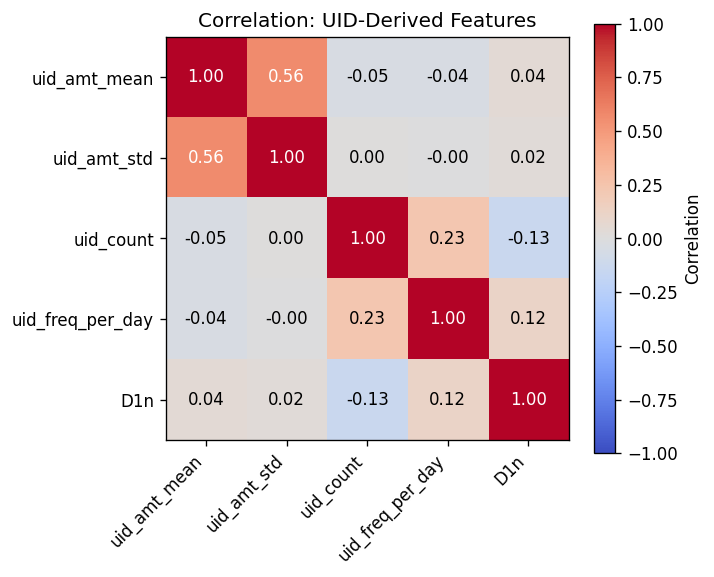


Pairs with |correlation| > 0.5:
  uid_amt_mean <-> uid_amt_std: 0.56


In [ ]:
# Check 4a: correlation among UID-derived features -- rule out credit-splitting

uid_features = ['uid_amt_mean', 'uid_amt_std', 'uid_count', 'uid_freq_per_day', 'D1n']
uid_features = [f for f in uid_features if f in X_train.columns]

corr_matrix = X_train[uid_features].corr()
print('Correlation matrix -- UID-derived features:')
print(corr_matrix.round(2).to_string())

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(uid_features)))
ax.set_yticks(range(len(uid_features)))
ax.set_xticklabels(uid_features, rotation=45, ha='right')
ax.set_yticklabels(uid_features)
for i in range(len(uid_features)):
    for j in range(len(uid_features)):
        ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', ha='center', va='center',
                color='white' if abs(corr_matrix.iloc[i, j]) > 0.5 else 'black')
plt.colorbar(im, label='Correlation')
plt.title('Correlation: UID-Derived Features')
plt.tight_layout()
plt.savefig('../reports/uid_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

high_corr_pairs = []
for i in range(len(uid_features)):
    for j in range(i+1, len(uid_features)):
        if abs(corr_matrix.iloc[i, j]) > 0.5:
            high_corr_pairs.append((uid_features[i], uid_features[j], corr_matrix.iloc[i, j]))

print(f'\nPairs with |correlation| > 0.5:')
if high_corr_pairs:
    for f1, f2, c in high_corr_pairs:
        print(f'  {f1} <-> {f2}: {c:.2f}')
else:
    print('  None -- UID features are largely independent of each other.')

In [ ]:
# Check 4b: Top-N stability -- does SHAP/weight agreement hold beyond Top 10?

print('=== SHAP (median) vs. weight: overlap at different Top-N thresholds ===\n')

weight_df = importance_dfs['weight']

for top_n in [10, 20, 30]:
    shap_top    = set(median_rank.head(top_n)['feature'])
    weight_top  = set(weight_df.head(top_n)['feature'])
    overlap     = shap_top & weight_top
    print(f'Top {top_n:2d}: overlap = {len(overlap)}/{top_n} '
          f'({len(overlap)/top_n:.0%})  |  shared: {sorted(overlap)}')

print('\nInterpretation: if overlap percentage is stable or improves at larger N,')
print('the agreement between SHAP and weight-importance is a robust pattern, not')
print('a coincidence of which exact 10 features happened to rank highest.')

=== SHAP (median) vs. weight: overlap at different Top-N thresholds ===

Top 10: overlap = 5/10 (50%)  |  shared: ['D1n', 'TransactionAmt', 'card1', 'uid_amt_mean', 'uid_amt_std']
Top 20: overlap = 12/20 (60%)  |  shared: ['C1', 'C13', 'D1n', 'TransactionAmt', 'addr1_freq', 'card1', 'card1_freq', 'card2', 'card2_freq', 'uid_amt_mean', 'uid_amt_std', 'uid_count']
Top 30: overlap = 21/30 (70%)  |  shared: ['C1', 'C13', 'C14', 'C2', 'D10', 'D15', 'D1n', 'D2', 'D4', 'P_emaildomain_freq', 'TransactionAmt', 'addr1', 'addr1_freq', 'card1', 'card1_freq', 'card2', 'card2_freq', 'dist1', 'uid_amt_mean', 'uid_amt_std', 'uid_count']

Interpretation: if overlap percentage is stable or improves at larger N,
the agreement between SHAP and weight-importance is a robust pattern, not
a coincidence of which exact 10 features happened to rank highest.


## Local Explanation -- Waterfall Plot

Decomposes one prediction into per-feature contributions, the kind of
auditable, transaction-level explanation the EU AI Act requires for
high-risk decisions.


In [17]:
# ── Pick an example: a fraud transaction correctly flagged with high confidence ─

proba_sample = xgb_model.predict_proba(X_sample)[:, 1]
y_sample     = y_test.iloc[sample_idx].values

# True positives: actual fraud, predicted as high-risk
tp_mask = (y_sample == 1) & (proba_sample > 0.8)
tp_indices = np.where(tp_mask)[0]

print(f'Found {len(tp_indices)} high-confidence true positives in sample')

example_idx = tp_indices[0]
print(f'\nExample transaction:')
print(f'  Predicted fraud probability: {proba_sample[example_idx]:.3f}')
print(f'  Actual label: {"FRAUD" if y_sample[example_idx] == 1 else "Legitimate"}')
print(f'  TransactionAmt: ${X_sample.iloc[example_idx]["TransactionAmt"]:.2f}')

Found 161 high-confidence true positives in sample

Example transaction:
  Predicted fraud probability: 0.907
  Actual label: FRAUD
  TransactionAmt: $250.00


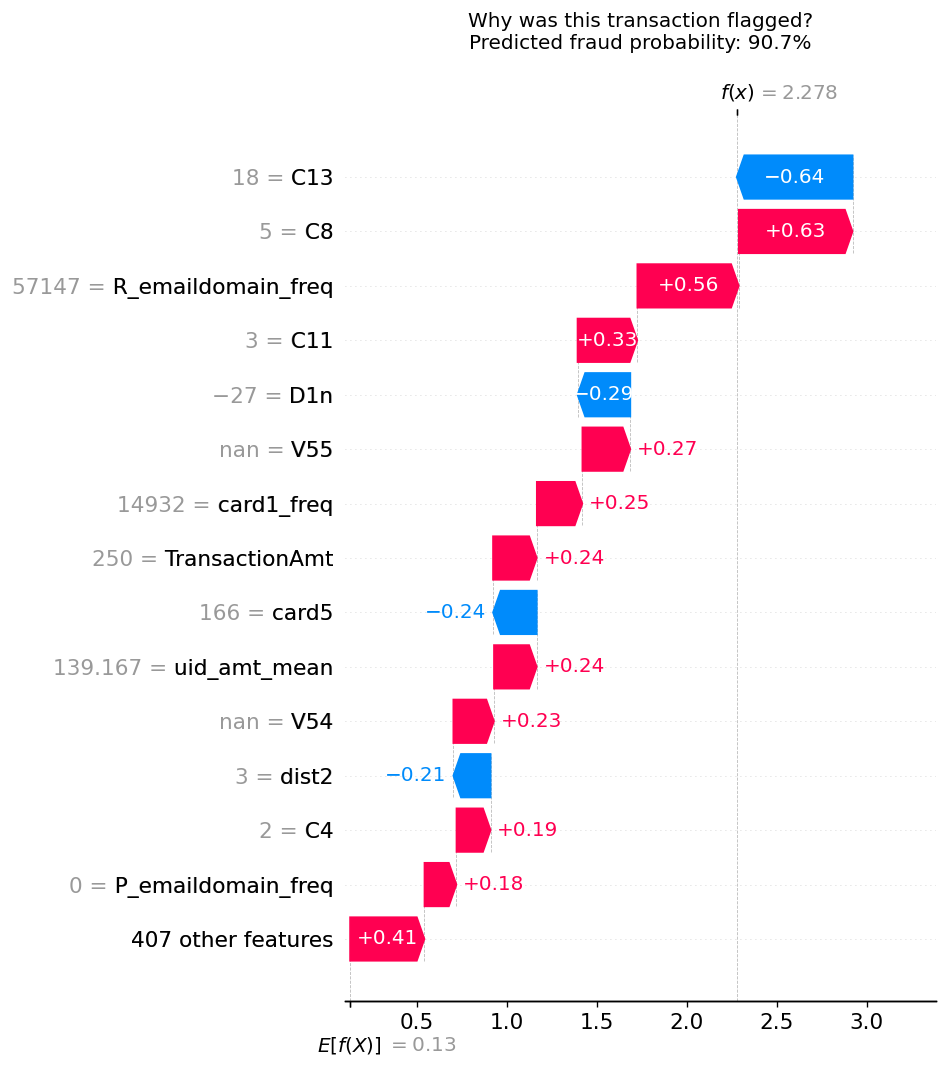

Saved: reports/shap_waterfall.png


In [ ]:
# Waterfall plot for the example transaction

fig = plt.figure(figsize=(10, 8))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[example_idx],
        base_values=explainer.expected_value,
        data=X_sample.iloc[example_idx].values,
        feature_names=FEATURES
    ),
    max_display=15,
    show=False
)
plt.title(f'Why was this transaction flagged?\n'
          f'Predicted fraud probability: {proba_sample[example_idx]:.1%}',
          fontsize=12, pad=20)
plt.tight_layout()
plt.savefig('../reports/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: reports/shap_waterfall.png')

In [ ]:
# Plain-language explanation (the kind a compliance report would need)

example_shap = pd.DataFrame({
    'feature': FEATURES,
    'shap_value': shap_values[example_idx],
    'feature_value': X_sample.iloc[example_idx].values
}).sort_values('shap_value', key=abs, ascending=False)

print('=== Top 5 factors driving this fraud prediction ===\n')
for _, row in example_shap.head(5).iterrows():
    direction = 'increased' if row['shap_value'] > 0 else 'decreased'
    print(f"  {row['feature']:25s} = {row['feature_value']:>10.3f}  "
          f"-> {direction} fraud score by {abs(row['shap_value']):.3f}")

=== Top 5 factors driving this fraud prediction ===

  C13                       =     18.000  -> decreased fraud score by 0.644
  C8                        =      5.000  -> increased fraud score by 0.632
  R_emaildomain_freq        =  57147.000  -> increased fraud score by 0.563
  C11                       =      3.000  -> increased fraud score by 0.332
  D1n                       =    -27.000  -> decreased fraud score by 0.293


: 

## EU AI Act Compliance Mapping

Credit/payment decision systems are classified as high-risk AI under the
EU AI Act, which requires transparency, human oversight, and documentation.

| Requirement | How this notebook addresses it |
|---|---|
| Transparency | SHAP decomposes every prediction into signed, additive feature contributions |
| Human oversight | Waterfall plots give a reviewer a concrete basis to confirm/overrule a decision |
| Documentation | Global SHAP summary documents which features the model relies on overall |
| Bias monitoring | Not yet implemented -- noted as future work (stratify SHAP by demographic proxies) |

This covers technical explainability. Full compliance also requires a risk
management system, data governance documentation, and conformity
assessment beyond the scope of this notebook. SHAP also explains the
model's reasoning but does not guarantee the underlying features are free
of indirect bias.
